# Definindo o problema

Desenvolvimento de um modelo de Deep Learning para a classificação ou predição de propriedades em sequências de proteínas.

## Modelo Predição Interação Proteína-Proteína

Vamos criar um modelo simples para tentar predizer quando existe interação entre duas proteínas.  

#### Importando Bibliotecas

### Importando as Bibliotecas Necessárias

In [ ]:
# Importa a biblioteca PyTorch, uma das principais ferramentas para criação e treinamento de modelos de Deep Learning.
import torch # Biblioteca de Deep Learning que oferece suporte para criação de tensores, treinamento de redes neurais e uso de GPU para acelerar os cálculos.

# Importa o módulo de redes neurais do PyTorch.
# O apelido "nn" significa "Neural Networks" (Redes Neurais).
import torch.nn as nn # Contém diversas classes e funções prontas para construção de modelos neurais, como camadas densas, convolucionais, funções de perda e muito mais.

# Importa o módulo de funções do PyTorch.
# O apelido "F" é usado para acessar funções matemáticas e operações comuns em redes neurais.
import torch.nn.functional as F # Fornece funções importantes para Deep Learning, como funções de ativação (ReLU, Softmax), cálculo de perdas e operações matemáticas sem precisar criar classes.

# Importa a biblioteca Pandas, usada para manipulação e análise de dados em formato de tabelas.
import pandas as pd # Biblioteca essencial para trabalhar com dados estruturados em DataFrames, permitindo leitura, filtragem, limpeza e análise de dados.

# Importa a biblioteca NumPy, muito usada para computação numérica eficiente.
import numpy as np # Biblioteca fundamental para operações matemáticas, manipulação de arrays multidimensionais e cálculos vetorizados de alta performance.

# Importa a função train_test_split do scikit-learn.
# Essa função é usada para dividir os dados em conjuntos de treino e teste.
from sklearn.model_selection import train_test_split # Ferramenta importante para separar os dados e avaliar se o modelo consegue generalizar bem para dados nunca vistos.

# Importa métricas de avaliação para modelos de classificação.
# roc_auc_score mede a capacidade do modelo de separar classes.
# average_precision_score mede a qualidade das previsões em tarefas desbalanceadas.
from sklearn.metrics import roc_auc_score, average_precision_score # Contém métricas utilizadas para avaliar o desempenho de modelos de Machine Learning e Deep Learning.

# Importa Dataset e DataLoader do PyTorch.
# Dataset organiza os dados.
# DataLoader carrega os dados em lotes (batches) durante o treinamento.
from torch.utils.data import Dataset, DataLoader # Ferramentas essenciais para gerenciamento eficiente dos dados durante o treinamento, especialmente em grandes volumes de dados.

# Importa a biblioteca Matplotlib para criação de gráficos e visualizações.
import matplotlib.pyplot as plt # Biblioteca amplamente utilizada para gerar gráficos, visualizar métricas de treinamento e analisar resultados do modelo.

# Importa a biblioteca Seaborn, baseada no Matplotlib.
# Ela facilita a criação de gráficos estatísticos mais bonitos e intuitivos.
import seaborn as sns # Biblioteca de visualização de dados que simplifica a criação de gráficos estatísticos avançados e melhora a estética das visualizações.

In [ ]:
# Definindo variável ou realizando operação: AMINOACIDOS
AMINOACIDOS = "ACDEFGHIKLMNPQRSTVWY" # Total 20

# Caractéres especiáis <PAD> é um token para adicionar pad e <UNk> para token desconhecido
# Nessa etapa vamos fazer a tokenização
# Definindo variável ou realizando operação: PAD
PAD = "<PAD>"
# Definindo variável ou realizando operação: UNK
UNK = "<UNK>"

# Definindo variável ou realizando operação: VOCAB
VOCAB = [PAD, UNK] + list(AMINOACIDOS)
# Definindo variável ou realizando operação: stoi
stoi = {c: i for i, c in enumerate(VOCAB)}
# Definindo variável ou realizando operação: itos
itos = {i: c for c, i in stoi.items()}

#### 1° Modelo:

Primeiro modelo que vamos fazer consiste em utilizar CNNs para realizar o encoder das sequências e adicionar cross-attention para tentar identificar quais os resíduos de A focam em quais resíduos de B

In [ ]:
## Primeiro vamos observar como é nosso dataset e pensar como vamos fazer
# um modelo para realizar essa análise
dataset_negativo = pd.read_csv(r'/content/negative_protein_sequences.csv')
dataset_positivo = pd.read_csv(r'/content/positive_protein_sequences.csv')

dataset_positivo.head()

,protein_sequences_1,protein_sequences_2
0,MESSKKMDSPGALQTNPPLKLHTDRSAGTPVFVPEQGGYKEKFVKT...,MARPHPWWLCVLGTLVGLSATPAPKSCPERHYWAQGKLCCQMCEPG...
1,MVMSSYMVNSKYVDPKFPPCEEYLQGGYLGEQGADYYGGGAQGADF...,MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...
2,MNRHLWKSQLCEMVQPSGGPAADQDVLGEESPLGKPAMLHLPSEQG...,MEGGRRARVVIESKRNFFLGAFPTPFPAEHVELGRLGDSETAMVPG...
3,MAPPSTREPRVLSATSATKSDGEMVLPGFPDADSFVKFALGSVVAV...,MLFYSFFKSLVGKDVVVELKNDLSICGTLHSVDQYLNIKLTDISVT...
4,MQSGPRPPLPAPGLALALTLTMLARLASAASFFGENHLEVPVATAL...,MQTIKCVVVGDGAVGKTCLLISYTTNKFPSEYVPTVFDNYAVTVMI...


In [ ]:
## Vamos concatenar esses 2 datasets e adicionar uma coluna com o label
dataset_positivo['Label'] = 1
dataset_negativo['Label'] = 0

dataset_completo = pd.concat([dataset_positivo, dataset_negativo], ignore_index=True)

## Mais para frente será necessário ver qual a maior sequência que desejamos
# sendo assim vou ver qual a maior sequência do dataset
max_len_1 = dataset_completo["protein_sequences_1"].str.len().max()
max_len_2 = dataset_completo["protein_sequences_2"].str.len().max()

maior_seq = max(max_len_1, max_len_2)

## Agora separar o que é dados de treino e o que é dados teste
train_df, val_df = train_test_split(dataset_completo, test_size=0.2,
                                    random_state=42, stratify=dataset_completo["Label"],
                                    shuffle=True)

In [ ]:
## Vamos definir os aminoacidos
# Definindo variável ou realizando operação: AMINOACIDOS
AMINOACIDOS = "ACDEFGHIKLMNPQRSTVWY" # Total 20

# Caractéres especiáis <PAD> é um token para adicionar pad e <UNk> para token desconhecido
# Nessa etapa vamos fazer a tokenização
PAD = "<PAD>"
UNK = "<UNK>"


VOCAB = [PAD, UNK] + list(AMINOACIDOS)

# stoi (String TO Integer): Mapeia cada caractere para um número inteiro único.
# O 'enumerate' gera os pares (índice, caractere). A compreensão de dicionário 
# coloca o caractere (c) como chave e o índice (i) como valor.
# -> Usado na ENTRADA: converte o texto puro para números antes de treinar a rede.
stoi = {c: i for i, c in enumerate(VOCAB)}

# itos (Integer TO String): Dicionário reverso, desfaz o que o 'stoi' fez.
# Pega os itens de 'stoi' e inverte a relação: índice (i) vira chave, caractere (c) vira valor.
# -> Usado na SAÍDA: converte as previsões numéricas da rede de volta para texto legível.
itos = {i: c for c, i in stoi.items()}


PAD_ID = stoi[PAD]
UNK_ID = stoi[UNK]

def encode_protein(seq: str, max_len: int):
  """
  Função: encode_protein
  Descrição: Função responsável por executar a lógica de encode_protein dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  """
    Função que recebe uma sequência e devolve ela tokenizada
    seq: Parâmetro que recebe a Sequência
    max_len: Limite de sequência analisada
  """
  # Subdivide a sequência em cada letra e deixa tudo maiúscula
  seq = seq.strip().upper()
  # Armazena qual o token e caso não estiver no vocabulário coloca <UNK>
  ids = [stoi.get(c, UNK_ID) for c in seq][:max_len]
  # Attn é uma máscara para saber o que é padding e o que não é
  attn = [1] * len(ids)

  # Adicionar Padding até preencher a sequência
  if len(ids) < max_len:
    pad_n = max_len - len(ids)
    ids += [PAD_ID] * pad_n
    attn += [0] * pad_n

  return torch.tensor(ids, dtype=torch.long), torch.tensor(attn, dtype=torch.float)

# Vamos testar o funcionamento
seq_aleatoria = "HIKACDLMNPÇ" # Perceba que Ç não estpa no Vocabulário definido
tamanho = len(seq_aleatoria) + 3
print(encode_protein(seq_aleatoria, tamanho))

(tensor([ 8,  9, 10,  2,  3,  4, 11, 12, 13, 14,  1,  0,  0,  0]), tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.]))


In [ ]:
# ============================================================
# Vamos arrumar o dataset
# ============================================================

# Neste projeto vamos utilizar um dataset de interação proteína-proteína (PPI - Protein Protein Interaction).
# Dataset utilizado:
# https://www.kaggle.com/datasets/spandansureja/ppi-dataset
#
# O objetivo do modelo será aprender padrões entre pares de proteínas
# para prever se elas interagem biologicamente ou não.

# ============================================================
# Criação da classe personalizada do Dataset
# ============================================================

# Toda vez que trabalhamos com PyTorch, é muito comum criar uma classe
# personalizada herdando de Dataset.
#
# Isso permite organizar os dados e facilitar o carregamento durante o treino.

class PPIDataset(Dataset):
  """
  Classe personalizada para manipulação do dataset de interação proteína-proteína (PPI).

  Esta classe é responsável por:
  - Armazenar os dados.
  - Processar as sequências de proteínas.
  - Converter as sequências em representações numéricas.
  - Entregar os dados no formato esperado pelo modelo.
  """

  def __init__(self, df, max_len=512):
    """
    Método construtor da classe.

    Parâmetros:
    ----------
    df : pandas.DataFrame
        DataFrame contendo as proteínas e seus rótulos.

    max_len : int
        Tamanho máximo permitido para cada sequência proteica.
        Sequências maiores serão truncadas e menores serão preenchidas.
    """

    # reset_index(drop=True)
    # Reinicia os índices do DataFrame.
    # Isso evita problemas caso o DataFrame original tenha índices quebrados.
    self.df = df.reset_index(drop=True)

    # Define o tamanho máximo das sequências.
    self.max_len = max_len

  # ============================================================
  # Retorna o tamanho do dataset
  # ============================================================

  def __len__(self):
    """
    Retorna a quantidade total de amostras no dataset.

    Esta função é obrigatória quando criamos uma classe herdando de Dataset.

    O DataLoader usa essa função para saber:
    - Quantas amostras existem.
    - Quantos batches precisam ser criados.
    """

    return len(self.df)

  # ============================================================
  # Retorna uma amostra individual do dataset
  # ============================================================

  def __getitem__(self, idx):
    """
    Retorna uma única amostra do dataset.

    Parâmetros:
    ----------
    idx : int
        Índice da linha desejada.

    Fluxo desta função:
    -------------------
    1. Seleciona uma linha do DataFrame.
    2. Obtém as duas proteínas.
    3. Obtém o rótulo (interage ou não).
    4. Converte as sequências em representação numérica.
    5. Retorna tudo em formato de dicionário.
    """

    # Seleciona a linha correspondente ao índice solicitado.
    row = self.df.iloc[idx]

    # Extrai:
    # - Sequência da proteína A
    # - Sequência da proteína B
    # - Label da interação
    #
    # Label normalmente:
    # 1 = interagem
    # 0 = não interagem
    seqA, seqB, y = (
        row['protein_sequences_1'],
        row['protein_sequences_2'],
        int(row["Label"])
    )

    # ============================================================
    # Conversão das proteínas para representação numérica
    # ============================================================

    # encode_protein()
    # Função responsável por transformar aminoácidos em tokens numéricos.
    #
    # Ela provavelmente retorna:
    #
    # idsA  -> tokens numéricos da proteína
    # maskA -> máscara indicando quais posições possuem informação válida
    #
    # A máscara é importante porque as proteínas possuem tamanhos diferentes.

    idsA, maskA = encode_protein(seqA, self.max_len)
    idsB, maskB = encode_protein(seqB, self.max_len)

    # ============================================================
    # Retorno final
    # ============================================================

    # Retornamos um dicionário contendo:
    #
    # idsA  -> tokens da proteína A
    # maskA -> máscara da proteína A
    # idsB  -> tokens da proteína B
    # maskB -> máscara da proteína B
    # label -> valor alvo da classificação

    return{
        "idsA": idsA,
        "maskA": maskA,

        "idsB": idsB,
        "maskB": maskB,

        # Converte o label para tensor float.
        #
        # dtype=torch.float é importante porque muitas funções de loss
        # esperam valores float.
        "label": torch.tensor(y, dtype=torch.float)
    }

# ============================================================
# Criação dos datasets de treino e validação
# ============================================================

# Dataset de treino
#
# max_len=1000
# Define o tamanho máximo das proteínas.
#
# Sequências maiores que isso:
# -> serão truncadas.
#
# Sequências menores:
# -> receberão padding.
train_ds = PPIDataset(train_df, max_len=1000)

# Dataset de validação
val_ds = PPIDataset(val_df, max_len=1000)

# ============================================================
# Criação dos DataLoaders
# ============================================================

# O DataLoader é responsável por:
#
# - Carregar os dados em batches.
# - Embaralhar os dados.
# - Melhorar eficiência do treinamento.
# - Facilitar uso em GPU.

# ------------------------------------------------------------
# DataLoader de treino
# ------------------------------------------------------------

train_loader = DataLoader(
    train_ds,

    # Quantidade de amostras processadas por vez.
    batch_size=32,

    # shuffle=True
    # Embaralha os dados a cada época.
    #
    # Isso ajuda o modelo a não decorar a ordem das amostras.
    shuffle=True
)

# ------------------------------------------------------------
# DataLoader de validação
# ------------------------------------------------------------

val_loader = DataLoader(
    val_ds,

    # Mesmo batch size utilizado no treino.
    batch_size=32,

    # shuffle=False
    #
    # Na validação não precisamos embaralhar os dados,
    # pois não estamos treinando o modelo.
    shuffle=False
)

In [ ]:
train_ds.__getitem__(2)

{'idsA': tensor([12, 17,  2, 21, 14, 10, 17, 21, 13, 14,  6,  4,  4,  4,  7,  5,  4,  5,
          7,  2, 16, 14,  2, 14, 20, 16,  4,  2, 16,  4, 11, 14,  4,  7, 14,  4,
          2, 14,  2,  4, 16, 15, 15, 21, 11, 16, 15,  5, 19, 11, 16, 16,  2,  5,
          2, 18,  2,  2, 17, 18, 17, 16, 17, 11,  2, 11, 12, 21,  5, 17,  5, 10,
         19,  7, 19,  2, 17, 17,  5,  5, 11,  2, 16, 15, 16,  7, 19, 11,  5, 16,
         18,  5, 10, 12, 19,  4, 10, 12,  4, 15,  4, 11, 10,  9, 17, 15, 10,  8,
          9, 13, 17,  9, 10, 17, 19,  6,  7,  7, 11, 19, 13, 21,  6, 10, 17, 10,
         14, 19,  5, 18, 14, 14,  5, 15, 13,  7, 18, 11, 18, 17, 15, 14, 13, 13,
         16, 11, 10,  5,  2,  9, 17, 18, 17, 10,  5, 15,  5,  2, 10, 21, 15,  2,
         17,  8, 14, 13, 11, 16, 10, 11,  4,  4, 18,  4, 14, 19, 14, 16,  7,  2,
          7, 17,  2, 12, 17, 18,  4,  2, 21, 14, 10, 13, 14,  8, 11, 16,  2, 21,
          8, 15, 10,  9,  4, 17, 13, 11,  4,  5, 11, 17, 12,  7, 11,  7, 16, 11,
         10,  4,  9,

In [ ]:
# ============================================================
# Vamos criar nosso modelo inicial
# ============================================================

# O primeiro componente do modelo será o Encoder.
#
# A função do Encoder é transformar as sequências de proteínas
# em representações numéricas mais ricas e informativas.
#
# Em Deep Learning isso é chamado de:
# -> Feature Extraction
# -> Aprendizado de Representações
#
# Neste caso utilizaremos:
# - Embedding
# - Camadas Convolucionais (CNN)
#
# A ideia é capturar padrões locais presentes nas sequências,
# como combinações importantes de aminoácidos.

class CNNEncoder(nn.Module):
  """
  Encoder baseado em Redes Neurais Convolucionais (CNN).

  Objetivo:
  ----------
  Transformar sequências de proteínas em representações vetoriais
  mais expressivas para o modelo aprender padrões biológicos.

  Estratégia utilizada:
  ---------------------
  1. Embedding das proteínas.
  2. Convoluções com múltiplos tamanhos de kernel.
  3. Combinação das informações extraídas.
  4. Projeção final para representação latente.
  """

  def __init__(self, vocab_size, emb_dim=64, hidden=128, dropout=0.2):
    """
    Método construtor da classe.

    Parâmetros:
    ----------
    vocab_size : int
        Quantidade total de tokens possíveis.
        Exemplo:
        aminoácidos + tokens especiais.

    emb_dim : int
        Dimensão do embedding.
        Cada aminoácido será representado por um vetor de tamanho emb_dim.

    hidden : int
        Quantidade de filtros das convoluções.

    dropout : float
        Taxa de dropout utilizada para reduzir overfitting.
    """

    # Inicializa a classe pai (nn.Module)
    super().__init__()

    # ============================================================
    # Camada de Embedding
    # ============================================================

    # nn.Embedding transforma IDs inteiros em vetores densos.
    #
    # Exemplo:
    # A -> [0.12, -0.45, 0.88, ...]
    #
    # Isso permite que o modelo aprenda relações semânticas
    # entre aminoácidos.

    self.embedding = nn.Embedding(

        # Número total de tokens possíveis
        vocab_size,

        # Tamanho do vetor de embedding
        emb_dim,

        # padding_idx
        #
        # Define qual token representa padding.
        #
        # O embedding desse token não será atualizado durante o treino.
        padding_idx=PAD_ID
    )

    # ============================================================
    # Camadas Convolucionais
    # ============================================================

    # Aqui usamos 3 convoluções independentes.
    #
    # Cada convolução possui um kernel diferente:
    #
    # kernel_size=3 -> captura padrões pequenos
    # kernel_size=5 -> captura padrões médios
    # kernel_size=7 -> captura padrões maiores
    #
    # Isso é semelhante ao conceito de n-gramas em NLP.
    #
    # A CNN consegue detectar padrões locais importantes
    # dentro da sequência proteica.

    self.convs = nn.ModuleList([

        # --------------------------------------------------------
        # Convolução 1
        # --------------------------------------------------------

        nn.Conv1d(

            # Número de canais de entrada
            emb_dim,

            # Número de filtros de saída
            hidden,

            # Tamanho da janela convolucional
            kernel_size=3,

            # Padding para manter o mesmo tamanho da sequência
            padding=1
        ),

        # --------------------------------------------------------
        # Convolução 2
        # --------------------------------------------------------

        nn.Conv1d(
            emb_dim,
            hidden,
            kernel_size=5,
            padding=2
        ),

        # --------------------------------------------------------
        # Convolução 3
        # --------------------------------------------------------

        nn.Conv1d(
            emb_dim,
            hidden,
            kernel_size=7,
            padding=3
        )
    ])

    # ============================================================
    # Camada de projeção final
    # ============================================================

    # Após concatenar todas as convoluções,
    # teremos um vetor grande.
    #
    # Então usamos uma projeção linear para:
    #
    # - Reduzir dimensionalidade
    # - Misturar informações das convoluções
    # - Criar uma representação mais compacta

    self.proj = nn.Sequential(

        # Camada linear
        #
        # Entrada:
        # 3 * hidden
        #
        # Porque temos:
        # 3 convoluções independentes
        nn.Linear(3 * hidden, hidden),

        # GELU
        #
        # Função de ativação 
        nn.GELU(),

        # Dropout
        #
        # Desliga neurônios aleatoriamente durante o treino.
        #
        # Isso ajuda a evitar overfitting.
        nn.Dropout(dropout)
    )

  # ============================================================
  # Forward Pass
  # ============================================================

  def forward(self, ids):
    """
    Define o fluxo de dados do modelo.

    Parâmetros:
    ----------
    ids : Tensor
        Tensor contendo os IDs das proteínas.

    Formato esperado:
    -----------------
    (batch_size, comprimento_seq)

    Retorno:
    --------
    Tensor com representação aprendida da sequência.
    """

    # ============================================================
    # Embedding
    # ============================================================

    # Entrada:
    # (batch, comprimento_seq)
    #
    # Saída:
    # (batch, comprimento_seq, emb_dim)

    x = self.embedding(ids)

    # ============================================================
    # Ajuste de dimensões
    # ============================================================

    # Conv1D do PyTorch espera:
    #
    # (batch, canais, comprimento)
    #
    # Então precisamos trocar as dimensões.

    x = x.transpose(1, 2)

    # Agora:
    # (batch, emb_dim, comprimento_seq)

    # ============================================================
    # Aplicação das convoluções
    # ============================================================

    feats = []

    for conv in self.convs:

      # Aplicação da convolução
      #
      # Saída:
      # (batch, hidden, comprimento_seq)

      h = conv(x)

      # Função de ativação GELU
      h = F.gelu(h)

      # Armazena saída da convolução
      feats.append(h)

    # ============================================================
    # Concatenação das features
    # ============================================================

    # Junta todas as saídas das convoluções.
    #
    # dim=1 significa:
    # concatenar no eixo dos canais/features.

    h = torch.cat(feats, dim=1)

    # Resultado:
    # (batch, 3*hidden, comprimento_seq)

    # ============================================================
    # Ajuste de dimensões novamente
    # ============================================================

    h = h.transpose(1, 2)

    # Agora:
    # (batch, comprimento_seq, 3*hidden)

    # ============================================================
    # Projeção final
    # ============================================================

    h = self.proj(h)

    # Resultado final:
    # (batch, comprimento_seq, hidden)

    return h

# ============================================================
# Verificando se o padding mantém o tamanho da sequência
# ============================================================

# Fórmula da saída de uma convolução:
#
# saída = [(entrada - kernel + 2*padding)/stride] + 1

# Tamanho original da sequência
tamanho_seq = 10

# ------------------------------------------------------------
# Kernel 3 com padding 1
# ------------------------------------------------------------

saida = (10 - 3 + (2*1))/1 + 1

# ------------------------------------------------------------
# Kernel 5 com padding 2
# ------------------------------------------------------------

saida2 = (10 - 5 + (2*2))/1 + 1

# Impressão dos resultados
print(saida, saida2)

# Resultado:
# 10.0 10.0
#
# Ou seja:
# o tamanho da sequência foi preservado.
#
# Isso é importante porque queremos manter alinhamento
# entre os aminoácidos e suas representações.

10.0 10.0


In [ ]:
# ============================================================
# Criando a Camada de Cross-Attention
# ============================================================

# Agora chegamos em uma das partes mais importantes do modelo:
# o mecanismo de Cross-Attention.
#
# A ideia principal aqui é:
#
# Fazer a proteína A "olhar" para a proteína B
# e aprender quais regiões possuem maior relação/interação.
#
# Isso é extremamente importante em tarefas de
# Protein-Protein Interaction (PPI),
# porque a interação entre proteínas normalmente depende
# de regiões específicas das sequências.

class CrossAttention(nn.Module):
  """
  Camada de Cross-Attention.

  Objetivo:
  ----------
  Permitir que uma proteína aprenda informações relevantes
  da outra proteína.

  Exemplo:
  --------
  Proteína A pode aprender:
  - quais aminoácidos da proteína B são importantes
  - quais regiões possuem maior compatibilidade
  - possíveis padrões de interação biológica
  """

  """
  Cross-Attention funciona da seguinte maneira:

  Temos:

  Q = Query
  K = Key
  V = Value

  A fórmula principal é:

  score[i,j] = (Q_i · K_j) / sqrt(d)

  Onde:
  -------
  Q_i -> representação do elemento i da proteína A
  K_j -> representação do elemento j da proteína B

  O score mede:
  -> o quanto dois resíduos/aminoácidos são relevantes entre si.

  Depois aplicamos softmax para transformar os scores
  em probabilidades de atenção.
  """

  def __init__(self, d_model=128):
    """
    Método construtor da camada de atenção.

    Parâmetros:
    ----------
    d_model : int
        Dimensão da representação interna do modelo.
    """

    super().__init__()

    # ============================================================
    # Camadas Lineares
    # ============================================================

    # Cada entrada será transformada em:
    #
    # Query (Q)
    # Key   (K)
    # Value (V)
    #
    # Isso é exatamente o mecanismo usado em Transformers.

    # Query
    self.Wq = nn.Linear(d_model, d_model)

    # Key
    self.Wk = nn.Linear(d_model, d_model)

    # Value
    self.Wv = nn.Linear(d_model, d_model)

  # ============================================================
  # Forward Pass
  # ============================================================

  def forward(self, A, B, maskB=None):
    """
    Executa o mecanismo de Cross-Attention.

    Parâmetros:
    ----------
    A : Tensor
        Representação da proteína A.

    B : Tensor
        Representação da proteína B.

    maskB : Tensor
        Máscara da proteína B.
        Usada para ignorar posições de padding.

    Formato esperado:
    -----------------
    A -> (batch, comprimento_A, d_model)
    B -> (batch, comprimento_B, d_model)
    """

    # ============================================================
    # Transformação em Q, K e V
    # ============================================================

    # Query vem da proteína A
    Q = self.Wq(A)

    # Key vem da proteína B
    K = self.Wk(B)

    # Value vem da proteína B
    V = self.Wv(B)

    # Obtém dimensão do modelo
    d = A.size(-1)

    # ============================================================
    # Cálculo dos Scores de Atenção
    # ============================================================

    # K.transpose(1, 2)
    #
    # Necessário para multiplicação matricial.
    #
    # Resultado:
    # (batch, comprimento_A, comprimento_B)

    scores = torch.matmul(
        Q,
        K.transpose(1, 2)
    ) / np.sqrt(d)

    # ============================================================
    # Aplicação da máscara
    # ============================================================

    # maskB:
    #
    # 1 -> posição válida
    # 0 -> padding
    #
    # Queremos impedir que o modelo "preste atenção"
    # em regiões de padding.

    if maskB is not None:

      # masked_fill substitui os valores das posições mascaradas.
      #
      # -1e9 gera valores extremamente negativos.
      #
      # Depois do softmax:
      # essas posições terão probabilidade ~0.

      scores = scores.masked_fill(
          maskB.unsqueeze(1) == 0,
          -1e9
      )

    # ============================================================
    # Softmax
    # ============================================================

    # Converte os scores em probabilidades.
    #
    # Agora temos:
    # "quanto cada aminoácido deve prestar atenção"

    attn = torch.softmax(scores, dim=-1)

    # ============================================================
    # Aplicação da Atenção
    # ============================================================

    # Multiplica os pesos de atenção pelos Values.
    #
    # Isso gera uma nova representação contextualizada.

    out = torch.matmul(attn, V)

    # Retorna:
    #
    # out  -> representação enriquecida
    # attn -> mapa de atenção

    return out, attn

# ============================================================
# Modelo Final de Predição de Interação Proteína-Proteína
# ============================================================

# Agora vamos juntar:
#
# - Encoder CNN
# - Cross-Attention
# - Pooling
# - Classificador Final
#
# para prever:
#
# "Essas duas proteínas interagem ou não?"

class PPIModel(nn.Module):
  """
  Modelo principal para predição de interação proteína-proteína.

  Fluxo geral:
  -------------
  1. Encoder gera embeddings das proteínas.
  2. Cross-Attention aprende relações entre elas.
  3. Pooling resume as sequências.
  4. Classificador gera a probabilidade final.
  """

  def __init__(
      self,
      vocab_size=len(VOCAB),
      emb_dim=64,
      hidden=128,
      dropout=0.25
  ):
    """
    Método construtor do modelo.
    """

    super().__init__()

    # ============================================================
    # Encoder compartilhado
    # ============================================================

    # O mesmo encoder será usado para:
    #
    # - proteína A
    # - proteína B
    #
    # Isso reduz quantidade de parâmetros
    # e ajuda o modelo a aprender representações gerais.

    self.encoder = CNNEncoder(
        vocab_size,
        emb_dim=emb_dim,
        hidden=hidden,
        dropout=dropout
    )

    # ============================================================
    # Cross-Attention bidirecional
    # ============================================================

    # crossA:
    # proteína A olha para proteína B

    self.crossA = CrossAttention(d_model=hidden)

    # crossB:
    # proteína B olha para proteína A

    self.crossB = CrossAttention(d_model=hidden)

    # ============================================================
    # Camada usada no Attention Pooling
    # ============================================================

    self.pool = nn.Linear(hidden, 1)

    # ============================================================
    # Classificador Final
    # ============================================================

    # Recebe:
    #
    # pooledA + pooledB
    #
    # Por isso:
    # 2 * hidden

    self.classifier = nn.Sequential(

        # Primeira camada
        nn.Linear(2*hidden, 256),

        nn.GELU(),

        nn.Dropout(dropout),

        # Segunda camada
        nn.Linear(256, 64),

        nn.GELU(),

        nn.Dropout(dropout),

        # Saída final
        #
        # 1 neurônio:
        # probabilidade de interação
        nn.Linear(64, 1)
    )

  # ============================================================
  # Attention Pooling
  # ============================================================

  def attn_pool(self, H, mask):
    """
    Realiza pooling baseado em atenção.

    Objetivo:
    ----------
    Aprender quais regiões da proteína são mais importantes.

    Em vez de simplesmente calcular média,
    o modelo aprende pesos para cada posição.
    """

    # H:
    # (batch, comprimento, dimensão)

    # ============================================================
    # Calcula score para cada posição
    # ============================================================

    scores = self.pool(H).squeeze(-1)

    # Resultado:
    # (batch, comprimento)

    # ============================================================
    # Remove posições de padding
    # ============================================================

    scores = scores.masked_fill(mask == 0, -1e9)

    # ============================================================
    # Softmax
    # ============================================================

    # Converte scores em pesos probabilísticos.

    w = torch.softmax(scores, dim=-1)

    # ============================================================
    # Soma ponderada
    # ============================================================

    # einsum realiza multiplicação ponderada:
    #
    # pooled = soma(w * H)

    pooled = torch.einsum(
        "bl,bld->bd",
        w,
        H
    )

    # pooled:
    # (batch, dimensão)

    return pooled, w

  # ============================================================
  # Forward Pass Completo
  # ============================================================

  def forward(
      self,
      idsA,
      maskA,
      idsB,
      maskB,
      return_expl=False
  ):
    """
    Fluxo completo do modelo.
    """

    # ============================================================
    # Encoder
    # ============================================================

    # Gera representação da proteína A
    HA = self.encoder(idsA)

    # Gera representação da proteína B
    HB = self.encoder(idsB)

    # ============================================================
    # Cross-Attention
    # ============================================================

    # A aprende olhando para B
    HA2, attnA = self.crossA(
        HA,
        HB,
        maskB=maskB
    )

    # B aprende olhando para A
    HB2, attnB = self.crossB(
        HB,
        HA,
        maskB=maskA
    )

    # ============================================================
    # Conexão Residual
    # ============================================================

    # Ideia semelhante à ResNet e Transformers.
    #
    # Mantemos:
    # - informação original
    # - informação contextual aprendida

    HA = HA + HA2
    HB = HB + HB2

    # ============================================================
    # Attention Pooling
    # ============================================================

    pooledA, wA = self.attn_pool(HA, maskA)

    pooledB, wB = self.attn_pool(HB, maskB)

    # ============================================================
    # Concatenação
    # ============================================================

    # Junta informações das duas proteínas.

    x = torch.cat(
        [pooledA, pooledB],
        dim=-1
    )

    # ============================================================
    # Classificação Final
    # ============================================================

    logits = self.classifier(x).squeeze(-1)

    # Sigmoid transforma logits em probabilidades.
    #
    # Resultado:
    # valores entre 0 e 1.

    prob = torch.sigmoid(logits)

    # ============================================================
    # Retorno simples
    # ============================================================

    if not return_expl:
        return prob, logits

    # ============================================================
    # Retorno explicável
    # ============================================================

    # Aqui retornamos:
    #
    # wA / wB
    # -> importância dos resíduos
    #
    # attnA_to_B
    # -> como A observa B
    #
    # attnB_to_A
    # -> como B observa A

    return prob, logits, {

        # Importância por aminoácido em A
        "wA": wA,

        # Importância por aminoácido em B
        "wB": wB,

        # Mapa de atenção A -> B
        "attnA_to_B": attnA,

        # Mapa de atenção B -> A
        "attnB_to_A": attnB,
    }

In [ ]:
### Vamos treinar nosso modelo, mas antes vamos criar as funções auxiliares
# tanto para treinar quanto para avaliação
def treinar_uma_epoca(model, loader, optimizer, device="cuda"):
  """
  Função: treinar_uma_epoca
  Descrição: Função responsável por executar a lógica de treinar_uma_epoca dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  model.train()
  total_loss = 0

  for batch in loader:
    idsA = batch["idsA"].to(device)
    maskA = batch["maskA"].to(device)
    idsB = batch["idsB"].to(device)
    maskB = batch["maskB"].to(device)
    y = batch["label"].to(device)

    prob, logits = model(idsA, maskA, idsB, maskB)
    loss = F.binary_cross_entropy_with_logits(logits, y)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    total_loss += loss.item() * y.size(0)
  return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device="cuda"):
  """
  Função: evaluate
  Descrição: Função responsável por executar a lógica de evaluate dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  model.eval()
  ys, ps = [], []

  for batch in loader:
      idsA = batch["idsA"].to(device)
      maskA = batch["maskA"].to(device)
      idsB = batch["idsB"].to(device)
      maskB = batch["maskB"].to(device)
      y = batch["label"].to(device)

      prob, _ = model(idsA, maskA, idsB, maskB)
      ys.append(y.cpu().numpy())
      ps.append(prob.cpu().numpy())

  y = np.concatenate(ys)
  p = np.concatenate(ps)

  return {
      "roc_auc": roc_auc_score(y, p),
      "pr_auc": average_precision_score(y, p),
  }


device = "cuda" if torch.cuda.is_available() else "cpu"
model = PPIModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

for epoch in range(1, 5):
  loss = treinar_uma_epoca(model, train_loader, optimizer, device=device)
  metrics = evaluate(model, val_loader, device=device)
  print(f"Epoch {epoch:02d} | loss={loss:.4f} | ROC-AUC={metrics['roc_auc']:.4f} | PR-AUC={metrics['pr_auc']:.4f}")

Epoch 01 | loss=0.4183 | ROC-AUC=0.9722 | PR-AUC=0.9732
Epoch 02 | loss=0.1751 | ROC-AUC=0.9874 | PR-AUC=0.9863
Epoch 03 | loss=0.1183 | ROC-AUC=0.9906 | PR-AUC=0.9894
Epoch 04 | loss=0.0968 | ROC-AUC=0.9919 | PR-AUC=0.9912


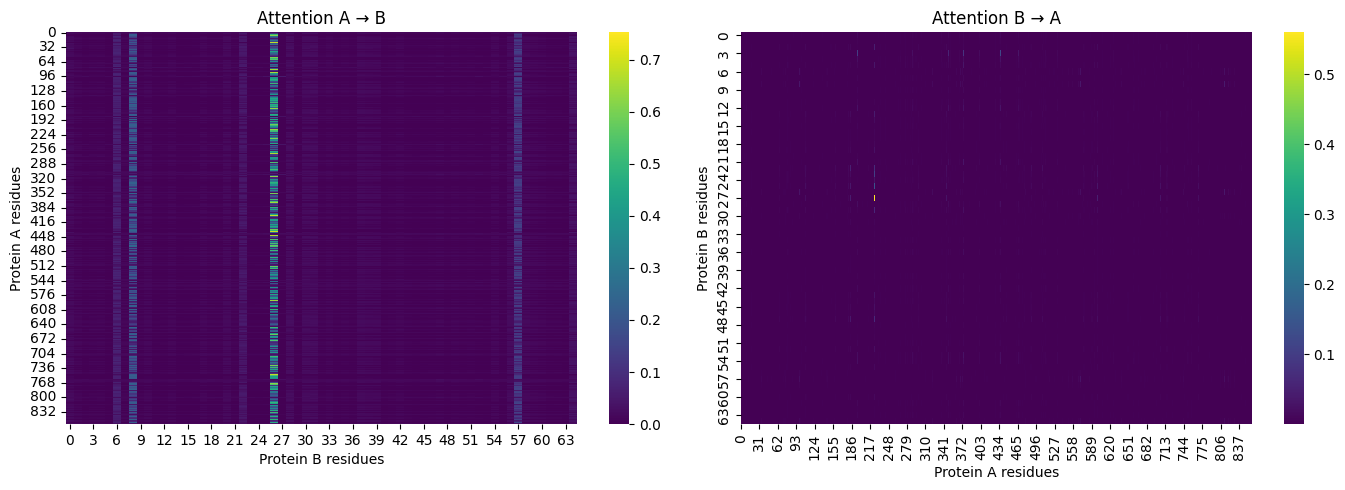

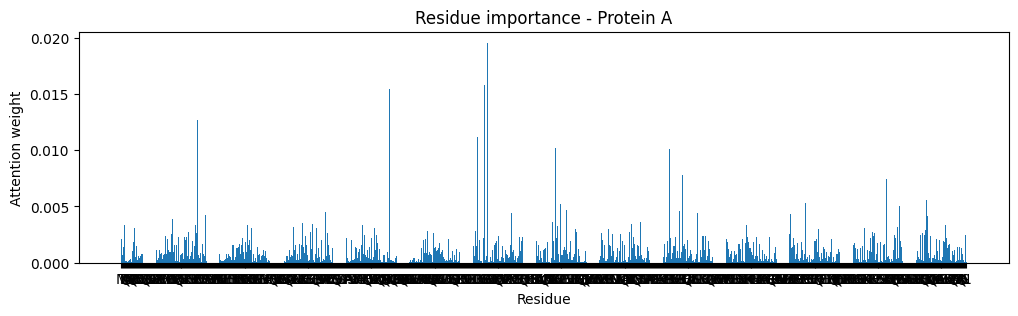

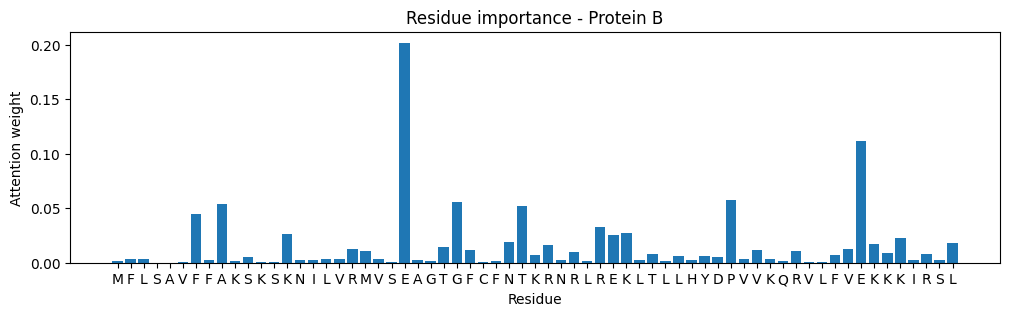

In [ ]:
# ============================================================
# Funções de Visualização e Interpretabilidade do Modelo
# ============================================================

# Agora vamos criar funções para visualizar:
#
# 1. Como a proteína A presta atenção na proteína B
# 2. Como a proteína B presta atenção na proteína A
# 3. Quais resíduos (aminoácidos) foram considerados mais importantes
#
# Isso é extremamente importante em Bioinformática,
# porque queremos interpretar biologicamente o comportamento do modelo.
#
# Em outras palavras:
#
# Não queremos apenas saber:
# "As proteínas interagem?"
#
# Queremos entender:
# "QUAIS regiões são importantes para essa interação?"

# ============================================================
# Função para visualizar mapas de Cross-Attention
# ============================================================

def plot_cross_attention(attn_dict, maskA, maskB, seqA, seqB, idx=0):
  """
  Plota os mapas de atenção entre duas proteínas.

  Objetivo:
  ----------
  Visualizar quais resíduos da proteína A
  estão prestando atenção na proteína B
  e vice-versa.

  Parâmetros:
  ----------
  attn_dict : dict
      Dicionário retornado pelo modelo contendo:
      - attnA_to_B
      - attnB_to_A

  maskA : Tensor
      Máscara da proteína A.

  maskB : Tensor
      Máscara da proteína B.

  seqA : list
      Sequência da proteína A.

  seqB : list
      Sequência da proteína B.

  idx : int
      Índice da amostra dentro do batch.
  """

  # ============================================================
  # Obtendo tamanho real das proteínas
  # ============================================================

  # A máscara possui:
  #
  # 1 -> posição válida
  # 0 -> padding
  #
  # Somando os valores:
  # obtemos o comprimento real da sequência.

  LA = int(maskA[idx].sum().item())
  LB = int(maskB[idx].sum().item())

  # ============================================================
  # Extraindo mapas de atenção
  # ============================================================

  # attnA:
  # mostra como A observa B

  attnA = attn_dict["attnA_to_B"][idx][:LA, :LB]

  # detach()
  # Remove do grafo computacional.

  # cpu()
  # Move tensor para CPU.

  # numpy()
  # Converte para NumPy para visualização.

  attnA = attnA.detach().cpu().numpy()

  # attnB:
  # mostra como B observa A

  attnB = attn_dict["attnB_to_A"][idx][:LB, :LA]
  attnB = attnB.detach().cpu().numpy()

  # ============================================================
  # Remove posições de padding das sequências
  # ============================================================

  seqA = seqA[:LA]
  seqB = seqB[:LB]

  # ============================================================
  # Criação da figura
  # ============================================================

  # figsize=(14,5)
  #
  # Define tamanho da imagem.
  #
  # ax:
  # cria dois gráficos lado a lado.

  fig, ax = plt.subplots(1, 2, figsize=(14,5))

  # ============================================================
  # Heatmap A -> B
  # ============================================================

  sns.heatmap(

      # Matriz de atenção
      attnA,

      # Paleta de cores
      cmap="viridis",

      # Eixo do gráfico
      ax=ax[0],

      # Labels dos aminoácidos
      # (comentados para evitar poluição visual)
      #
      # xticklabels=list(seqB),
      # yticklabels=list(seqA)
  )

  # Títulos e labels
  ax[0].set_title("Attention A → B")

  ax[0].set_xlabel("Protein B residues")

  ax[0].set_ylabel("Protein A residues")

  # ============================================================
  # Heatmap B -> A
  # ============================================================

  sns.heatmap(
      attnB,
      cmap="viridis",
      ax=ax[1],

      # xticklabels=list(seqA),
      # yticklabels=list(seqB)
  )

  ax[1].set_title("Attention B → A")

  ax[1].set_xlabel("Protein A residues")

  ax[1].set_ylabel("Protein B residues")

  # Ajusta espaçamento automaticamente
  plt.tight_layout()

  # Mostra figura
  plt.show()

# ============================================================
# Função para visualizar importância dos resíduos
# ============================================================

# Aqui vamos visualizar:
#
# Quais aminoácidos o modelo considerou mais importantes.
#
# Isso é obtido através dos pesos de atenção do pooling.

def plot_residue_importance(attn_dict, mask, seq, protein="A", idx=0):
  """
  Plota importância dos resíduos/aminoácidos.

  Objetivo:
  ----------
  Mostrar quais posições da proteína
  receberam maior peso de atenção.

  Parâmetros:
  ----------
  attn_dict : dict
      Dicionário contendo pesos de atenção.

  mask : Tensor
      Máscara da proteína.

  seq : list
      Sequência de aminoácidos.

  protein : str
      Define se estamos analisando:
      - proteína A
      - proteína B

  idx : int
      Índice da amostra no batch.
  """

    # ============================================================
    # Seleciona pesos da proteína correta
    # ============================================================

  if protein == "A":

      # Pesos de atenção da proteína A
      weights = attn_dict["wA"]

  else:

      # Pesos de atenção da proteína B
      weights = attn_dict["wB"]

  # ============================================================
  # Obtém comprimento real da sequência
  # ============================================================

  L = int(mask[idx].sum().item())

  # Remove padding da sequência
  seq = seq[:L]

  # Obtém pesos reais
  w = weights[idx][:L].detach().cpu().numpy()

  # ============================================================
  # Criação do gráfico
  # ============================================================

  plt.figure(figsize=(12,3))

  # Gráfico de barras
  plt.bar(range(L), w)

  # Coloca aminoácidos no eixo X
  plt.xticks(range(L), list(seq))

  # Título
  plt.title(f"Residue importance - Protein {protein}")

  # Labels
  plt.xlabel("Residue")

  plt.ylabel("Attention weight")

  # Mostra gráfico
  plt.show()

# ============================================================
# Obtendo um batch de validação
# ============================================================

# next(iter(val_loader))
#
# Pega o primeiro batch do DataLoader.

batch = next(iter(val_loader))

# ============================================================
# Move dados para o device
# ============================================================

# device pode ser:
#
# - CPU
# - GPU (CUDA)

idsA = batch["idsA"].to(device)

maskA = batch["maskA"].to(device)

idsB = batch["idsB"].to(device)

maskB = batch["maskB"].to(device)

# ============================================================
# Escolhendo amostra do batch
# ============================================================

idx = 0

# ============================================================
# Função de detokenização
# ============================================================

# O modelo trabalha com IDs numéricos.
#
# Mas para visualização precisamos converter
# os IDs novamente para aminoácidos.

def detokenize(ids):
  """
  Converte IDs numéricos em aminoácidos.

  Exemplo:
  --------
  [1, 5, 3] -> ['A', 'G', 'T']
  """

    # itos:
    #
    # index-to-string
    #
    # Mapeia:
    # índice -> aminoácido

  return [itos[int(i)] for i in ids]

# ============================================================
# Recuperando sequências originais
# ============================================================

seqA = detokenize(idsA[idx])

seqB = detokenize(idsB[idx])

# ============================================================
# Executando o modelo com explicabilidade
# ============================================================

# return_expl=True
#
# Faz o modelo retornar:
#
# - mapas de atenção
# - pesos de importância
# - explicações internas

#prob, logits, attn_dict = model(
#    idsA,
#    maskA,
#    idsB,
#    maskB,
#    return_expl=True
#)

# ============================================================
# Plotando mapas de atenção
# ============================================================

plot_cross_attention(
    attn_dict,

    seqA=seqA,
    seqB=seqB,

    maskA=maskA,
    maskB=maskB,

    idx=idx
)

# ============================================================
# Plotando importância da proteína A
# ============================================================

plot_residue_importance(
    attn_dict,

    mask=maskA,

    seq=seqA,

    protein="A",

    idx=idx
)

# ============================================================
# Plotando importância da proteína B
# ============================================================

plot_residue_importance(
    attn_dict,

    mask=maskB,

    seq=seqB,

    protein="B",

    idx=idx
)

# ============================================================
# Interpretação Biológica
# ============================================================

# Heatmaps:
#
# Regiões mais claras/intensas:
# -> maior atenção entre resíduos.
#
# Isso pode indicar:
# -> possíveis regiões de interação molecular.
#
# ------------------------------------------------------------
#
# Gráficos de importância:
#
# Barras maiores:
# -> aminoácidos considerados mais relevantes.
#
# Isso ajuda na interpretabilidade biológica
# e pode auxiliar descoberta de sítios funcionais.

In [ ]:
# ============================================================
# Obtendo o tamanho real das sequências
# ============================================================

# maskA e maskB possuem:
#
# 1 -> posição válida da proteína
# 0 -> padding
#
# Como todas as proteínas possuem tamanhos diferentes,
# usamos padding para padronizar o tamanho do batch.
#
# Porém:
# precisamos descobrir qual é o tamanho REAL da sequência,
# ignorando os paddings.

# ------------------------------------------------------------
# Comprimento real da proteína A
# ------------------------------------------------------------

LA = int(maskA[idx].sum().item())

# Explicação passo a passo:
#
# maskA[idx]
# -> seleciona a máscara da proteína A da amostra escolhida.
#
# Exemplo:
# tensor([1,1,1,1,1,0,0,0])
#
# .sum()
# -> soma os valores da máscara.
#
# Resultado:
# 5
#
# Isso significa:
# existem 5 aminoácidos reais.
#
# .item()
# -> converte tensor para valor Python.
#
# int(...)
# -> garante que o resultado seja inteiro.

# ------------------------------------------------------------
# Comprimento real da proteína B
# ------------------------------------------------------------

LB = int(maskB[idx].sum().item())

# Mesmo processo:
#
# Descobre quantos resíduos reais existem
# na proteína B.

# ============================================================
# Extraindo o mapa de atenção A → B
# ============================================================

# attn_dict["attnA_to_B"]
#
# Contém os mapas de atenção onde:
#
# proteína A observa proteína B.
#
# Formato:
# (batch, comprimento_A, comprimento_B)

attnA = attn_dict["attnA_to_B"][idx][:LA, :LB]

# Explicação:
#
# [idx]
# -> seleciona uma amostra específica do batch.
#
# [:LA, :LB]
# -> remove regiões de padding.
#
# Isso garante que visualizaremos apenas:
# aminoácidos reais.

# ------------------------------------------------------------
# Conversão para NumPy
# ------------------------------------------------------------

attnA = attnA.detach().cpu().numpy()

# detach()
# -> remove tensor do grafo computacional.
#
# Isso evita cálculo de gradientes.
#
# cpu()
# -> move tensor para CPU.
#
# numpy()
# -> converte tensor PyTorch em array NumPy.
#
# Necessário para visualização com matplotlib/seaborn.

# ============================================================
# Extraindo o mapa de atenção B → A
# ============================================================

# Agora fazemos o inverso:
#
# proteína B observando proteína A.

attnB = attn_dict["attnB_to_A"][idx][:LB, :LA]

# Dimensão:
# (comprimento_B, comprimento_A)

attnB = attnB.detach().cpu().numpy()

# Conversão para NumPy novamente.

# ============================================================
# Removendo padding das sequências
# ============================================================

# seqA e seqB ainda possuem posições de padding.
#
# Vamos manter apenas os aminoácidos reais.

seqA = seqA[:LA]

seqB = seqB[:LB]

# Exemplo:
#
# Antes:
# ['M', 'K', 'L', 'A', '<PAD>', '<PAD>']
#
# Depois:
# ['M', 'K', 'L', 'A']
#
# Isso é importante para:
#
# - visualizações corretas
# - alinhamento entre atenção e sequência
# - interpretação biológica adequada

In [ ]:
seqB[24:28]

['G', 'T', 'G', 'F']

Esse Modelo era bem simples tentanando fazer algo bem complexo como analisar proteinas. Outros modelos da literatura fazer exatamente isso. Vamos utilzar um modelo já feito que é o ESM2 um modelo de embeddings pré-treinados, para fazer a mesma predição e ver a diferença nos resultados

In [ ]:
### Importando algumas bibliotecas a mais
from transformers import AutoTokenizer, AutoModel # Para usar modelos pré-treinados de linguagem de proteínas

In [ ]:
# ============================================================
# Agora vamos refazer algumas funções
# ============================================================

# Nesta nova versão do projeto iremos utilizar:
#
# ESM2 (Evolutionary Scale Modeling)
#
# O ESM2 é um modelo Transformer treinado especificamente
# em sequências de proteínas.
#
# Ele funciona de forma semelhante aos modelos de linguagem
# usados em NLP (como BERT/GPT),
# porém treinado em aminoácidos.
#
# Isso permite obter embeddings extremamente ricos
# biologicamente.

# ============================================================
# Função para aplicar padding manualmente
# ============================================================

def pad_to_max_len(input_ids, attention_mask, max_len, pad_id):
  """
  Aplica padding ou truncamento em sequências.

  Objetivo:
  ----------
  Garantir que todas as sequências tenham
  exatamente o mesmo tamanho.

  Isso é necessário porque:
  redes neurais trabalham melhor com batches
  de dimensões fixas.

  Parâmetros:
  ----------
  input_ids : Tensor
      IDs tokenizados da proteína.

  attention_mask : Tensor
      Máscara indicando:
      1 -> token válido
      0 -> padding

  max_len : int
      Tamanho máximo permitido.

  pad_id : int
      Token utilizado para padding.
  """

  # ============================================================
  # Truncamento
  # ============================================================

  # Caso a sequência seja maior que max_len,
  # cortamos o excesso.

  if input_ids.size(0) > max_len:

    input_ids = input_ids[:max_len]

    attention_mask = attention_mask[:max_len]

  # ============================================================
  # Calcula quantidade de padding necessária
  # ============================================================

  pad_len = max_len - input_ids.size(0)

  # ============================================================
  # Aplicação do padding
  # ============================================================

  if pad_len > 0:

    # torch.full(...)
    #
    # Cria tensor preenchido com pad_id.

    input_ids = torch.cat([
        input_ids,

        torch.full(
            (pad_len,),
            pad_id,
            dtype=torch.long
        )
    ])

    # Para a máscara:
    #
    # 0 representa padding.

    attention_mask = torch.cat([
        attention_mask,

        torch.zeros(
            (pad_len,),
            dtype=torch.long
        )
    ])

  # Retorna sequência ajustada
  return input_ids, attention_mask

# ============================================================
# Dataset atualizado utilizando ESM2
# ============================================================

class PPIDataset(Dataset):
  """
  Dataset para interação proteína-proteína utilizando ESM2.

  Agora utilizamos:
  - tokenizer oficial do ESM2
  - tokens especiais
  - embeddings aprendidos pelo Transformer
  """

  def __init__(self, df: pd.DataFrame, tokenizer, max_len=512):
    """
    Método construtor do dataset.

    Parâmetros:
    ----------
    df : pd.DataFrame
        DataFrame contendo proteínas e labels.

    tokenizer :
        Tokenizer do ESM2.

    max_len : int
        Comprimento máximo das sequências.
    """

    # Reinicia índices
    self.df = df.reset_index(drop=True)

    # Tokenizer do ESM2
    self.tokenizer = tokenizer

    # Comprimento máximo
    self.max_len = max_len

    # ============================================================
    # PAD TOKEN do ESM2
    # ============================================================

    # Cada tokenizer possui um token específico de padding.

    self.pad_id = tokenizer.pad_token_id

  # ============================================================
  # Retorna tamanho do dataset
  # ============================================================

  def __len__(self):
    return len(self.df)

  # ============================================================
  # Retorna uma amostra
  # ============================================================

  def __getitem__(self, idx):

    # Seleciona linha do DataFrame
    row = self.df.iloc[idx]

    # Extrai proteínas e label
    seqA, seqB, y = (
        row['protein_sequences_1'],
        row['protein_sequences_2'],
        int(row["Label"])
    )

    # ============================================================
    # Tokenização das proteínas
    # ============================================================

    # add_special_tokens=True
    #
    # Adiciona tokens especiais usados pelo Transformer.
    #
    # Exemplo:
    # [CLS] proteína [SEP]

    tokA = self.tokenizer(
        seqA,
        return_tensors="pt",
        add_special_tokens=True
    )

    tokB = self.tokenizer(
        seqB,
        return_tensors="pt",
        add_special_tokens=True
    )

    # ============================================================
    # Remove dimensão extra
    # ============================================================

    # tokenizer retorna:
    # (1, comprimento)
    #
    # squeeze(0):
    # remove dimensão batch.

    input_ids_A = tokA["input_ids"].squeeze(0)

    attn_A = tokA["attention_mask"].squeeze(0)

    input_ids_B = tokB["input_ids"].squeeze(0)

    attn_B = tokB["attention_mask"].squeeze(0)

    # ============================================================
    # Padding manual
    # ============================================================

    input_ids_A, attn_A = pad_to_max_len(
        input_ids_A,
        attn_A,
        self.max_len,
        self.pad_id
    )

    input_ids_B, attn_B = pad_to_max_len(
        input_ids_B,
        attn_B,
        self.max_len,
        self.pad_id
    )

    # ============================================================
    # Retorno final
    # ============================================================

    return {

        "input_ids_A": input_ids_A,

        "attention_mask_A": attn_A,

        "input_ids_B": input_ids_B,

        "attention_mask_B": attn_B,

        "Label": torch.tensor(
            y,
            dtype=torch.float
        ),
    }

# ============================================================
# Bloco de Cross-Attention
# ============================================================

# Agora utilizaremos:
#
# nn.MultiheadAttention
#
# Implementação oficial do PyTorch para atenção multi-head,
# semelhante à usada em Transformers.

class CrossAttentionBlock(nn.Module):
  """
  Bloco de Cross-Attention baseado em Transformers.

  Objetivo:
  ----------
  Fazer uma proteína aprender padrões relevantes
  observando a outra proteína.
  """

  def __init__(self, d_model=320, n_heads=8, dropout=0.1):
    """
    Método construtor do bloco de atenção.
    """

    super().__init__()

    # ============================================================
    # Multi-Head Attention
    # ============================================================

    self.attn = nn.MultiheadAttention(

        # Dimensão dos embeddings
        embed_dim=d_model,

        # Número de cabeças de atenção
        num_heads=n_heads,

        # Dropout interno
        dropout=dropout,

        # batch_first=True
        #
        # Entrada:
        # (batch, seq, features)
        batch_first=True
    )

    # ============================================================
    # Layer Normalization
    # ============================================================

    self.ln = nn.LayerNorm(d_model)

    # ============================================================
    # Feed Forward Network
    # ============================================================

    # Estrutura típica de Transformers.

    self.ff = nn.Sequential(

        nn.Linear(d_model, 4*d_model),

        nn.GELU(),

        nn.Dropout(dropout),

        nn.Linear(4*d_model, d_model),

        nn.Dropout(dropout),
    )

    # Segunda normalização
    self.ln2 = nn.LayerNorm(d_model)

  # ============================================================
  # Forward Pass
  # ============================================================

  def forward(self, A, B,
              key_padding_mask_B=None,
              need_weights=True):
    """
    Executa Cross-Attention.

    A:
    ---
    Query

    B:
    ---
    Key + Value
    """

    # ============================================================
    # Atenção Multi-Head
    # ============================================================

    attn_out, attn_weights = self.attn(

        # Query
        query=A,

        # Key
        key=B,

        # Value
        value=B,

        # Máscara de padding
        key_padding_mask=key_padding_mask_B,

        # Retorna pesos de atenção
        need_weights=need_weights,

        # Mantém atenção separada por cabeça
        average_attn_weights=False,
    )

    # ============================================================
    # Residual + LayerNorm
    # ============================================================

    A = self.ln(A + attn_out)

    # ============================================================
    # Feed Forward
    # ============================================================

    A2 = self.ff(A)

    # ============================================================
    # Segunda conexão residual
    # ============================================================

    A = self.ln2(A + A2)

    return A, attn_weights

# ============================================================
# Modelo principal PPI com ESM2
# ============================================================

class PPIModel(nn.Module):
  """
  Modelo completo para predição de interação proteína-proteína.

  Componentes:
  -------------
  1. Encoder ESM2
  2. Cross-Attention bidirecional
  3. Attention Pooling
  4. Classificador final
  """

  def __init__(
      self,
      esm_name="facebook/esm2_t6_8M_UR50D",
      d_model=320,
      n_heads=8,
      dropout=0.2,
      freeze_esm=True
  ):

    super().__init__()

    # ============================================================
    # Tokenizer ESM2
    # ============================================================

    self.tokenizer = AutoTokenizer.from_pretrained(
        esm_name,
        do_lower_case=False
    )

    # ============================================================
    # Modelo ESM2 pré-treinado
    # ============================================================

    self.esm = AutoModel.from_pretrained(esm_name)

    # ============================================================
    # Congelamento do ESM
    # ============================================================

    # freeze_esm=True
    #
    # Evita treinar o Transformer inteiro.
    #
    # Isso:
    # - reduz custo computacional
    # - evita overfitting
    # - acelera treinamento

    if freeze_esm:

      for p in self.esm.parameters():
        p.requires_grad = False

    # ============================================================
    # Cross-Attention bidirecional
    # ============================================================

    self.cross_A_to_B = CrossAttentionBlock(
        d_model=d_model,
        n_heads=n_heads,
        dropout=dropout
    )

    self.cross_B_to_A = CrossAttentionBlock(
        d_model=d_model,
        n_heads=n_heads,
        dropout=dropout
    )

    # ============================================================
    # Attention Pooling
    # ============================================================

    self.poolA = nn.Sequential(
        nn.Linear(d_model, 1)
    )

    self.poolB = nn.Sequential(
        nn.Linear(d_model, 1)
    )

    # ============================================================
    # Classificador Final
    # ============================================================

    self.classifier = nn.Sequential(

        nn.Linear(2*d_model, 512),

        nn.GELU(),

        nn.Dropout(dropout),

        nn.Linear(512, 128),

        nn.GELU(),

        nn.Dropout(dropout),

        nn.Linear(128, 1),
    )

  # ============================================================
  # Encoder ESM2
  # ============================================================

  def encode(self, input_ids, attention_mask):
    """
    Obtém embeddings do ESM2.
    """

    out = self.esm(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    # last_hidden_state:
    #
    # representação contextualizada da sequência.

    return out.last_hidden_state

  # ============================================================
  # Attention Pooling
  # ============================================================

  def attn_pool(self, H, attention_mask, pool_layer):

    # Score de atenção
    scores = pool_layer(H).squeeze(-1)

    # Ignora padding
    scores = scores.masked_fill(
        attention_mask == 0,
        -1e9
    )

    # Softmax
    w = torch.softmax(scores, dim=-1)

    # Soma ponderada
    pooled = torch.einsum("bl,bld->bd", w, H)

    return pooled, w

  # ============================================================
  # Forward Pass
  # ============================================================

  def forward(
      self,
      input_ids_A,
      attention_mask_A,
      input_ids_B,
      attention_mask_B,
      return_explanations=False
  ):

      # ============================================================
      # Embeddings ESM2
      # ============================================================

      HA = self.encode(
          input_ids_A,
          attention_mask_A
      )

      HB = self.encode(
          input_ids_B,
          attention_mask_B
      )

      # ============================================================
      # Máscaras de padding
      # ============================================================

      key_padding_B = (attention_mask_B == 0)

      key_padding_A = (attention_mask_A == 0)

      # ============================================================
      # Cross-Attention
      # ============================================================

      HA2, attn_A_to_B = self.cross_A_to_B(
          HA,
          HB,
          key_padding_mask_B=key_padding_B
      )

      HB2, attn_B_to_A = self.cross_B_to_A(
          HB,
          HA,
          key_padding_mask_B=key_padding_A
      )

      # ============================================================
      # Pooling
      # ============================================================

      pooledA, wA = self.attn_pool(
          HA2,
          attention_mask_A,
          self.poolA
      )

      pooledB, wB = self.attn_pool(
          HB2,
          attention_mask_B,
          self.poolB
      )

      # ============================================================
      # Concatenação
      # ============================================================

      x = torch.cat([pooledA, pooledB], dim=-1)

      # ============================================================
      # Classificação Final
      # ============================================================

      logits = self.classifier(x).squeeze(-1)

      probs = torch.sigmoid(logits)

      # ============================================================
      # Retorno simples
      # ============================================================

      if not return_explanations:
          return probs, logits

      # ============================================================
      # Explicabilidade
      # ============================================================

      # Média entre as cabeças de atenção.

      attn_map_A_to_B = attn_A_to_B.mean(dim=1)

      attn_map_B_to_A = attn_B_to_A.mean(dim=1)

      return probs, logits, {

          "wA": wA,

          "wB": wB,

          "attn_A_to_B": attn_map_A_to_B,

          "attn_B_to_A": attn_map_B_to_A,
      }

# ============================================================
# Função de Treinamento
# ============================================================

def train_one_epoch(model, loader, optimizer, device="cuda"):
  """
  Executa uma época de treinamento.
  """

  # Coloca modelo em modo treino
  model.train()

  total_loss = 0.0

  for batch in loader:

    # ============================================================
    # Move batch para GPU/CPU
    # ============================================================

    idsA = batch["input_ids_A"].to(device)

    maskA = batch["attention_mask_A"].to(device)

    idsB = batch["input_ids_B"].to(device)

    maskB = batch["attention_mask_B"].to(device)

    y = batch["Label"].to(device)

    # ============================================================
    # Forward Pass
    # ============================================================

    probs, logits = model(
        idsA, maskA,
        idsB, maskB
    )

    # ============================================================
    # Loss
    # ============================================================

    # BCEWithLogits:
    # ideal para classificação binária.

    loss = F.binary_cross_entropy_with_logits(
        logits,
        y
    )

    # ============================================================
    # Backpropagation
    # ============================================================

    optimizer.zero_grad()

    loss.backward()

    # Atualiza pesos
    optimizer.step()

    # Acumula loss total
    total_loss += loss.item() * y.size(0)

  # Retorna loss média
  return total_loss / len(loader.dataset)

# ============================================================
# Função de Avaliação
# ============================================================

@torch.no_grad()
def evaluate(model, loader, device="cuda"):
  """
  Avalia o modelo.
  """

  # Modo avaliação
  model.eval()

  ys, ps = [], []

  for batch in loader:

    idsA = batch["input_ids_A"].to(device)

    maskA = batch["attention_mask_A"].to(device)

    idsB = batch["input_ids_B"].to(device)

    maskB = batch["attention_mask_B"].to(device)

    y = batch["Label"].to(device)

    # ============================================================
    # Inferência
    # ============================================================

    probs, logits = model(
        idsA, maskA,
        idsB, maskB
    )

    # Armazena labels reais
    ys.append(
        batch["Label"]
        .detach()
        .cpu()
        .numpy()
    )

    # Armazena probabilidades
    ps.append(
        probs
        .detach()
        .cpu()
        .numpy()
    )

  # ============================================================
  # Concatenação
  # ============================================================

  y = np.concatenate(ys)

  p = np.concatenate(ps)

  # ============================================================
  # Métricas
  # ============================================================

  return {

      # ROC-AUC
      #
      # Mede capacidade de separação entre classes.
      "roc_auc": roc_auc_score(y, p),

      # PR-AUC
      #
      # Muito útil em datasets desbalanceados.
      "pr_auc": average_precision_score(y, p),
  }

In [ ]:
# ============================================================
# Definindo dispositivo de execução
# ============================================================

# Aqui verificamos se existe uma GPU disponível.
#
# torch.cuda.is_available()
# retorna:
#
# True  -> GPU disponível
# False -> apenas CPU disponível

device = "cuda" if torch.cuda.is_available() else "cpu"

# Resultado:
#
# device = "cuda"
# ou
# device = "cpu"
#
# Utilizar GPU acelera MUITO o treinamento,
# especialmente em Transformers como o ESM2.

# ============================================================
# Nome do modelo ESM2
# ============================================================

# Modelo escolhido:
#
# facebook/esm2_t6_8M_UR50D
#
# Esse modelo:
#
# - possui aproximadamente 8 milhões de parâmetros
# - é relativamente leve
# - foi treinado em milhões de proteínas
#
# Link:
# https://huggingface.co/facebook/esm2_t6_8M_UR50D

esm_name = "facebook/esm2_t6_8M_UR50D"

# ============================================================
# Carregando o tokenizer do ESM2
# ============================================================

# O tokenizer é responsável por:
#
# - transformar aminoácidos em tokens numéricos
# - adicionar tokens especiais
# - criar attention masks
#
# Exemplo:
#
# "MKTLL"
# ->
# [CLS, 12, 4, 18, 9, 9, SEP]

tokenizer = AutoTokenizer.from_pretrained(

    # Nome do modelo
    esm_name,

    # Proteínas são case-sensitive.
    #
    # Não queremos converter letras para minúsculo.
    do_lower_case=False
)

# ============================================================
# Criação dos datasets
# ============================================================

# Dataset de treino
train_ds = PPIDataset(

    # DataFrame de treino
    train_df,

    # Tokenizer do ESM2
    tokenizer=tokenizer,

    # Comprimento máximo das proteínas
    max_len=1000
)

# Dataset de validação
val_ds = PPIDataset(
    val_df,
    tokenizer=tokenizer,
    max_len=1000
)

# ============================================================
# Função customizada de collate
# ============================================================

# O DataLoader recebe amostras individuais.
#
# O collate_fn define:
# "como juntar várias amostras em um batch"

def collate_fn(batch):
  """
  Junta múltiplas amostras em um batch.

  Objetivo:
  ----------
  Converter lista de dicionários em
  tensores organizados por batch.

  Exemplo:
  --------
  Antes:
  [
    {"input_ids": tensor(...)},
    {"input_ids": tensor(...)}
  ]

  Depois:
  {
    "input_ids": tensor(batch, seq_len)
  }
  """

  # ============================================================
  # Obtém chaves do dicionário
  # ============================================================

  keys = batch[0].keys()

  # Dicionário final
  out = {}

  # ============================================================
  # Empilha tensores
  # ============================================================

  for k in keys:

      # torch.stack(...)
      #
      # Junta vários tensores em um novo eixo.
      #
      # dim=0:
      # cria dimensão batch.

      out[k] = torch.stack(

          [b[k] for b in batch],

          dim=0
      )

  return out

# ============================================================
# Criação dos DataLoaders
# ============================================================

# batch_size=4
#
# Como ESM2 é pesado,
# utilizamos batch pequeno para economizar memória GPU.

train_loader = DataLoader(

    train_ds,

    # Quantidade de amostras por batch
    batch_size=4,

    # Embaralha dados no treino
    shuffle=True,

    # Função customizada de batch
    collate_fn=collate_fn
)

val_loader = DataLoader(

    val_ds,

    batch_size=4,

    # Validação normalmente não precisa shuffle
    shuffle=False,

    collate_fn=collate_fn
)

# ============================================================
# Criação do modelo
# ============================================================

model = PPIModel(

    # Nome do modelo ESM2
    esm_name=esm_name,

    # freeze_esm=True
    #
    # Congela pesos do Transformer.
    #
    # Apenas as camadas novas serão treinadas.
    freeze_esm=True

# Move modelo para GPU/CPU
).to(device)

# ============================================================
# Otimizador
# ============================================================

# AdamW:
#
# Versão moderna do Adam.
#
# Muito utilizada em Transformers.

optimizer = torch.optim.AdamW(

    # Apenas parâmetros treináveis
    #
    # Isso ignora pesos congelados do ESM2.
    [p for p in model.parameters() if p.requires_grad],

    # Learning Rate
    lr=3e-4
)

# ============================================================
# Variável para armazenar melhor score
# ============================================================

best = 0.0

# ============================================================
# Loop principal de treinamento
# ============================================================

# range(1, 6)
#
# Treinaremos por:
# 5 épocas

for epoch in range(1, 6):

    # ============================================================
    # Treinamento
    # ============================================================

    loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        device=device
    )

    # ============================================================
    # Avaliação
    # ============================================================

    metrics = evaluate(

        model,

        val_loader,

        device=device
    )

    # ============================================================
    # Escolhe métrica principal
    # ============================================================

    # PR-AUC costuma ser excelente
    # para datasets desbalanceados.

    score = metrics["pr_auc"]

    # ============================================================
    # Salvando melhor modelo
    # ============================================================

    if score > best:

        # Atualiza melhor score
        best = score

        # Salva pesos do modelo
        torch.save(

            model.state_dict(),

            "ppi_model.pt"
        )

    # ============================================================
    # Impressão dos resultados
    # ============================================================

    print(

        f"Epoch {epoch:02d} | "

        f"loss={loss:.4f} | "

        f"ROC-AUC={metrics['roc_auc']:.4f} | "

        f"PR-AUC={metrics['pr_auc']:.4f}"
    )

# ============================================================
# Explicação das métricas
# ============================================================

# LOSS
# ----
# Mede o erro do modelo.
#
# Quanto menor:
# melhor.

# ------------------------------------------------------------
#
# ROC-AUC
# --------
# Mede capacidade do modelo separar:
#
# - proteínas que interagem
# - proteínas que não interagem
#
# Valores:
#
# 0.5 -> aleatório
# 1.0 -> perfeito

# ------------------------------------------------------------
#
# PR-AUC
# -------
# Precision-Recall AUC
#
# Muito importante em datasets desbalanceados.
#
# Mede:
#
# - precisão
# - capacidade de encontrar exemplos positivos
#
# Quanto maior:
# melhor.

# ============================================================
# Salvamento do modelo
# ============================================================

# model.state_dict()
#
# Salva apenas:
# - pesos
# - parâmetros
#
# Arquivo gerado:
#
# ppi_model.pt
#
# Depois ele pode ser carregado usando:
#
# model.load_state_dict(torch.load("ppi_model.pt"))

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | loss=0.2802 | ROC-AUC=0.9806 | PR-AUC=0.9785
Epoch 02 | loss=0.1479 | ROC-AUC=0.9862 | PR-AUC=0.9864
